In [2]:
import time
import numpy as np
import math
import mujoco
import mujoco.viewer

import mediapy as media
import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

from IPython.display import clear_output

clear_output()

from robotblockset.mujoco.scene_pymujoco_sim import mujoco_scene
from robotblockset.mujoco.robots_pymujoco_sim import panda

import genesis as gs
from robotblockset.genesis.robots_genesis import panda as panda_genesis

np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [3]:
it = 0
def CaptureRobot_gen(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtf, vtf
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtf = gs.utils.tensor_to_array(r.robot_entity.links[-1].get_pos())
        vtf = gs.utils.tensor_to_array(r.robot_entity.links[-1].get_vel())
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtf = np.vstack((xtf, gs.utils.tensor_to_array(r.robot_entity.links[-1].get_pos())))
        vtf = np.vstack((vtf, gs.utils.tensor_to_array(r.robot_entity.links[-1].get_vel())))
    it += 1

    

In [4]:
it = 0
def CaptureRobot_flex(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtf, vtf
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtf = r.scene.data.sensor("flex_pos").data
        vtf = r.scene.data.sensor("flex_vel").data
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtf = np.vstack((xtf, r.scene.data.sensor("flex_pos").data))
        vtf = np.vstack((vtf, r.scene.data.sensor("flex_vel").data))
    it += 1

In [5]:
SCENE_PATH = get_rbs_path() + "/mujoco/mjcf_models/panda_flex_scene.xml"
SHOW_VIEWER = True

In [6]:
scene1 = mujoco_scene(SCENE_PATH, verbose=2, show_viewer=SHOW_VIEWER, show_camera=None)
r1 = panda(scene=scene1, robot_name="panda", JointNames="auto")
r1.JMove(r1.q_home)

[RBS_DEBUG] [1773421373.137211800] [MuJoCo Scene]: Model loaded successfully.
[RBS_DEBUG] [1773421373.571674109] [MuJoCo Scene]: Viewer started.
[RBS_INFO] [1773421373.571674109] [panda_PyMuJoCo]: Robot connected to MuJoCo


0

In [7]:
r1.Restart(u=r1.q_home)
r1.Wait(2)
r1.SetCaptureCallback(CaptureRobot_flex)
r1.ResetTime()
it = 0
r1.StartCapture()
r1.GoTo_q(r1.q_home + 0.1, wait=1)
r1.StopCapture()
tt1 = tt
qt1 = qt
rqt1 = rqt
qdt1 = qdt
rqdt1 = rqdt
xt1 = xt
vt1 = vt
xtf1 = xtf
vtf1 = vtf

In [8]:
########################## init ##########################
gs.init(backend=gs.gpu, logging_level="warning")

In [9]:
########################## create a scene ##########################
scene2 = gs.Scene(
    viewer_options=gs.options.ViewerOptions(
        camera_pos=(0, -3.5, 2.5),
        camera_lookat=(0.0, 0.0, 0.5),
        camera_fov=30,
        res=(960, 640),
        max_FPS=60,
    ),
    sim_options=gs.options.SimOptions(
        dt=scene1.model.opt.timestep,  # Same sampling time as MuJoCo
    ),
    show_viewer=SHOW_VIEWER,
)

########################## entities ##########################
franka = scene2.add_entity(
    gs.morphs.MJCF(
        # file  = 'xml/franka_emika_panda/panda.xml',
        file=SCENE_PATH,
    ),
)

########################## build ##########################
scene2.build()

r2 = panda_genesis(scene=scene2, robot_entity=franka, robot_name="panda")

[Genesis] [18:03:07] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [18:03:08] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_tool_finger_joint1`
[Genesis] [18:03:08] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_tool_finger_joint1`.
[Genesis] [18:03:08] [WARNING] (MJCF) Approximating tendon by joint actuator for `panda_tool_finger_joint2`
[Genesis] [18:03:08] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `panda_tool_finger_joint2`.


d:\Leon\Python\RBS\.venv\Lib\site-packages\trimesh\triangles.py:302: RuntimeWarning: invalid value encountered in divide
  center_mass = integrated[1:4] / volume


[Genesis] [18:03:11] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [18:03:22] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (4, 27), (4, 28), (4, 29), (4, 30), (4, 31), (5, 26), (5, 27), (5, 28), (5, 29), (5, 30), (6, 11), (7, 11), (12, 24), (13, 24), (14, 21), (14, 24), (15, 20), (15, 24), (16, 23), (17, 22), (18, 24), (19, 24), (20, 24), (21, 24). Consider tuning Morph option 'decompose_robot_error_threshold' or specify dedicated collision meshes. This behavior can be disabled by setting Morph option 'enable_neutral_collision=True'.


d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)
d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var MJ_GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)


[RBS_INFO] [1773421475.339547873] [panda_Genesis]: Robot connected to Genesis


In [10]:
r2.Restart(u=r2.q_home)
r2.Wait(2)
r2.SetCaptureCallback(CaptureRobot_gen)
r2.ResetTime()
it = 0
r2.StartCapture()
r2.GoTo_q(r2.q_home + 0.1, wait=1)
r2.StopCapture()
tt2 = tt
qt2 = qt
rqt2 = rqt
qdt2 = qdt
rqdt2 = rqdt
xt2 = xt
vt2 = vt
xtf2 = xtf
vtf2 = vtf


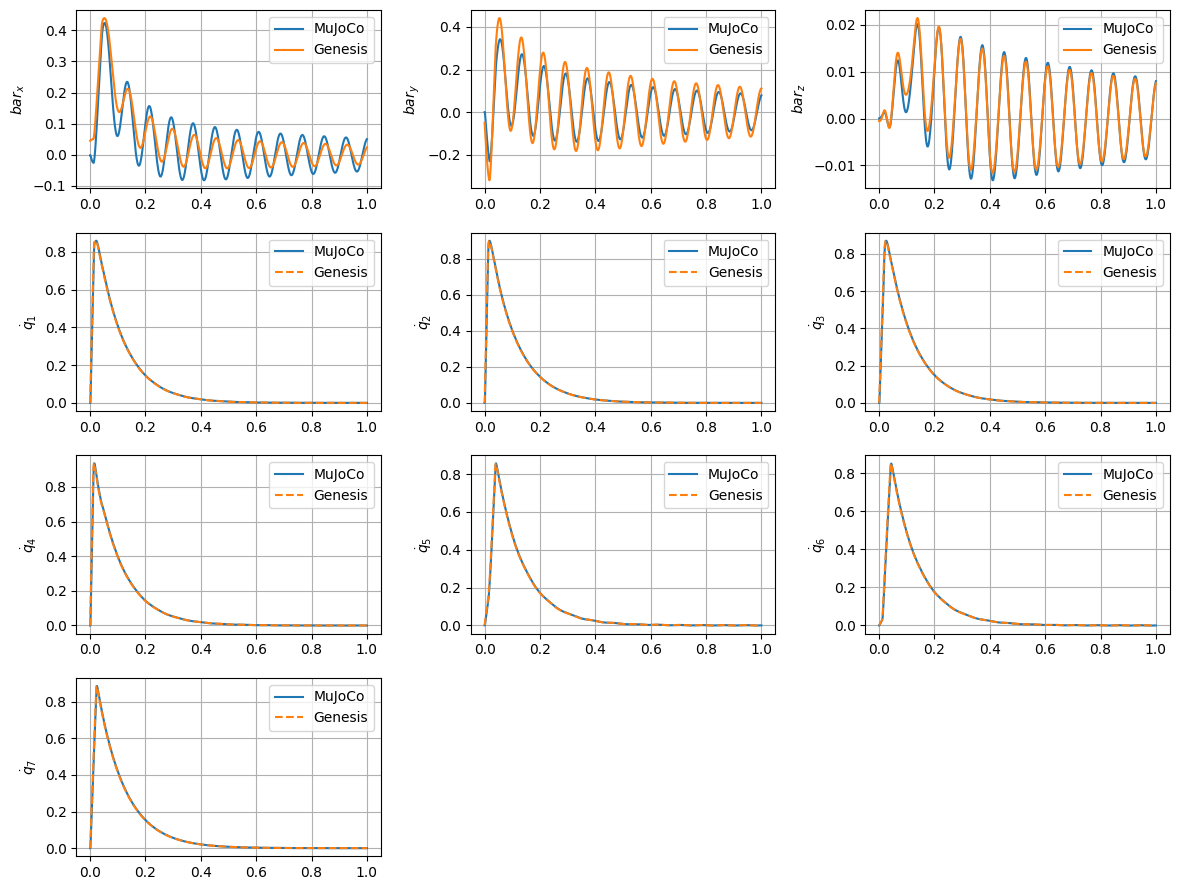

In [11]:
n = r1.nj + 3
cols = 3
rows = math.ceil(n / cols)
labs = ["x", "y", "z"]

fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(12, 9))

ax = axes.flatten()

for i in range(3):
    ax[i].plot(tt1, vtf1[:, i] - vt1[:, i], "-", label="MuJoCo")
    ax[i].plot(tt1, vtf2[:, i] - vt2[:, i], "-", label="Genesis")
    ax[i].set_ylabel(f"$bar_{labs[i]}$")
    ax[i].legend()
    ax[i].grid()
for i in range(r1.nj):
    ax[i + 3].plot(tt1, qdt1[:, i], "-", label="MuJoCo")
    ax[i + 3].plot(tt2, qdt2[:, i], "--", label="Genesis")
    ax[i + 3].set_ylabel(f"$\\dot q_{i+1}$")
    ax[i + 3].legend()
    ax[i + 3].grid()

plt.tight_layout()
for a in ax[n:]:
    a.axis("off")

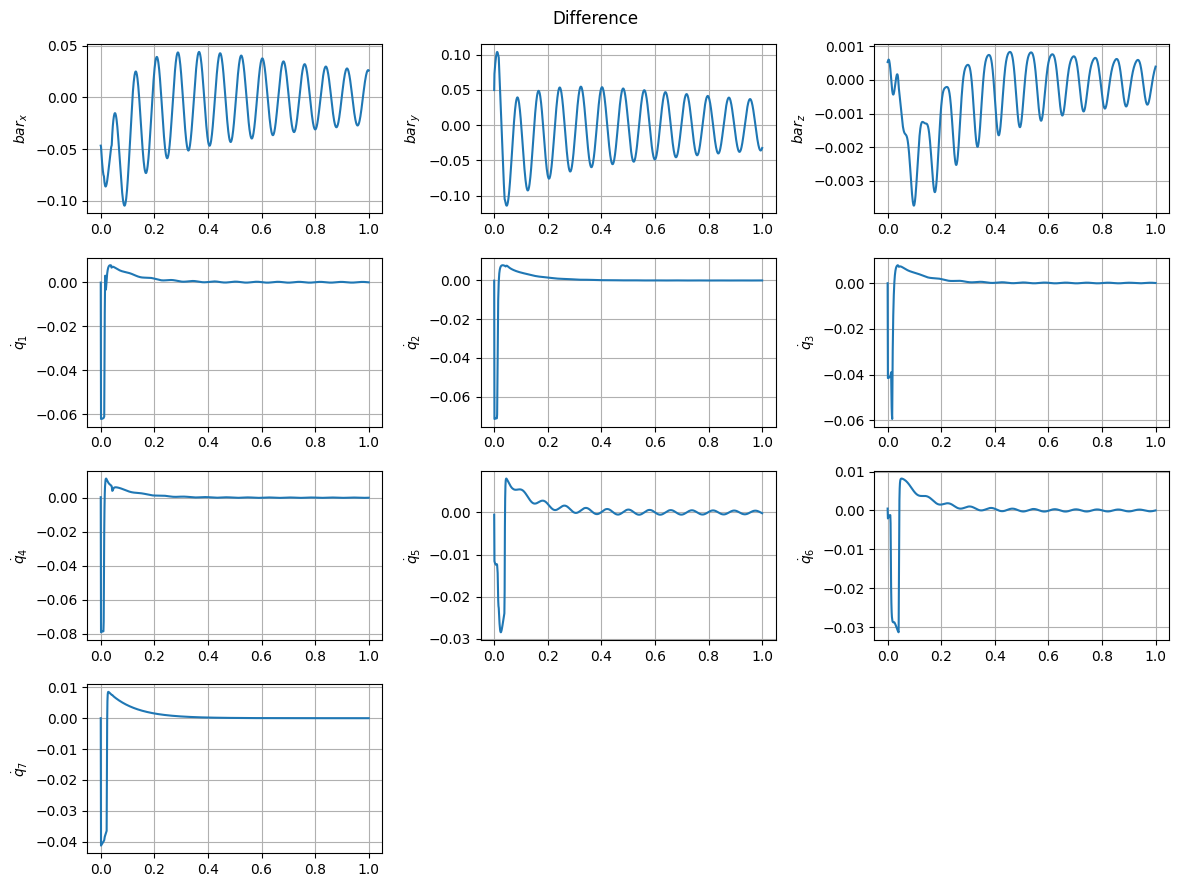

In [12]:
n = r1.nj + 3
cols = 3
rows = math.ceil(n / cols)
labs = ["x", "y", "z"]

fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(12, 9))

ax = axes.flatten()

for i in range(3):
    ax[i].plot(tt1, (vtf1[:, i] - vt1[:, i]) - (vtf2[:, i] - vt2[:, i]), "-")
    ax[i].set_ylabel(f"$bar_{labs[i]}$")
    ax[i].grid()
for i in range(r1.nj):
    ax[i + 3].plot(tt1, qdt1[:, i] - qdt2[:, i], "-")
    ax[i + 3].set_ylabel(f"$\\dot q_{i+1}$")
    ax[i + 3].grid()

fig.suptitle("Difference")
plt.tight_layout()
for a in ax[n:]:
    a.axis("off")

In [13]:
for i in range(1000):
    scene1.mj_step()

In [14]:
for i in range(1000):
    scene2.step()